## Partie exploitation des données
Les données téléchargées conrespondent à une étude sur différents mécidaments utilisés par des patients dans l'objectif de traiter certaines maladies.
Mon but ici est d'exploiter ces données en vue de mieux les comprendre, de les nettoyer en d'en extraire des informations pertinentes.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r'C:\Users\marie\OneDrive\Documents\GitHub\portfolio-data-ia-pharma\projet1-drug-data\data\drugsComTrain_raw.csv')
#aller dans le répertoire du fichier, faire clique droit et selectionner copier le chemin puis venir le coller ici sans oublier d'ajouter un r avant.


In [3]:
df.head(6)
#pour visualiser les 6 premiers lignes

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37
5,155963,Cialis,Benign Prostatic Hyperplasia,"""2nd day on 5mg started to work with rock hard...",2,28-Nov-15,43


In [4]:
df.tail(6)
#pour visualiser les 6 dernières

,uniqueID,drugName,condition,review,rating,date,usefulCount
161291,164345,Junel 1.5 / 30,Birth Control,"""This would be my second month on Junel. I&#03...",6,27-May-15,0
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,31-May-15,125
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,1-Nov-11,34
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,15-Mar-14,35
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,19-Sep-15,79
161296,215220,Lubiprostone,"Constipation, Chronic","""I&#039;ve had chronic constipation all my adu...",9,13-Dec-14,116


In [6]:
df.shape
#pour connaitre le nombre de lignes et de colonne du dataframe

(161297, 7)

### Test de la connexion à sqlite ###

In [51]:
import sqlite3
connexion = sqlite3.connect(r'C:\Users\marie\OneDrive\Documents\GitHub\portfolio-data-ia-pharma\projet1-drug-data\data\drugsComTrain_raw.db')
#pour établir la connection et pouvoir ouvrir le df
print(" Connexion OK")

 Connexion OK


In [52]:
df.to_sql('reviews', connexion, if_exists='replace', index=False)
#Une base de données nommé reviews a été créé
#index=false pour ne pas sauvegarder l'index Pandas (0, 1, 2...) comme colonne
#if_exists='replace' pour écraser la table si elle existe déja.
print("Base créée avec succès !")

Base créée avec succès !


In [53]:
resultat = pd.read_sql_query("SELECT drugName, condition, usefulCount, AVG(rating) as note_moyenne FROM reviews GROUP BY drugName ORDER BY note_moyenne DESC LIMIT 10", connexion)
#Une requete SQL pour visualiser comme je veux les données et ici je voulais visualiser les 10 medicaments avec un meilleur score moyen
print(resultat)

                          drugName                                condition  \
0                 Zyrtec-D 12 Hour                        Allergic Rhinitis   
1                           Zymine                                Allergies   
2                         Zutripro               Cough and Nasal Congestion   
3                         Zurampic                                     Gout   
4                          Zostrix                           Osteoarthritis   
5                       Zinc oxide                              Diaper Rash   
6  Zicam Extreme Congestion Relief                         Nasal Congestion   
7                           Zetran                                  Anxiety   
8                           Zenpep                     Chronic Pancreatitis   
9                          Zemaira  Alpha-1 Proteinase Inhibitor Deficiency   

   usefulCount  note_moyenne  
0           14          10.0  
1           11          10.0  
2            8          10.0  
3     

In [54]:
connexion.close()
#toujours fermer la connexion quand on a fini

In [55]:
#Importer tous les bibliothéques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Toutes les bibliothèques sont opérationnelles !")

Toutes les bibliothèques sont opérationnelles !


### EXPLORATION DES DONNEES ###

In [57]:
df.dtypes

uniqueID        int64
drugName       object
condition      object
review         object
rating          int64
date           object
usefulCount     int64
dtype: object

In [59]:
df.isnull().sum()
#donc il y'a 899 lignes où la condition est manquante, pour les autres colonnes pas de cases vides

uniqueID         0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64

In [60]:
df['condition'].isnull().sum()
#juste une confirmation

np.int64(899)

In [61]:
df['condition'].nunique()
#il y'a 884 conditions différentes dans ce data

884

In [62]:
df['condition'].head(8)

0    Left Ventricular Dysfunction
1                            ADHD
2                   Birth Control
3                   Birth Control
4               Opiate Dependence
5    Benign Prostatic Hyperplasia
6         Emergency Contraception
7                 Bipolar Disorde
Name: condition, dtype: object

In [63]:
df['drugName'].nunique()

3436

In [64]:
df['rating'].value_counts()

rating
10    50989
9     27531
1     21619
8     18890
7      9456
5      8013
2      6931
3      6513
6      6343
4      5012
Name: count, dtype: int64

In [65]:
connexion = sqlite3.connect(r'C:\Users\marie\OneDrive\Documents\GitHub\portfolio-data-ia-pharma\projet1-drug-data\data\drugsComTrain_raw.db')
df.to_sql('reviews', connexion, if_exists='replace', index=False)
resultat = pd.read_sql_query("SELECT drugName, condition FROM reviews WHERE rating = 10 LIMIT 10", connexion)
print(resultat)
connexion.close()

         drugName                     condition
0    Aripiprazole               Bipolar Disorde
1  L-methylfolate                    Depression
2     Lamotrigine               Bipolar Disorde
3       Nilotinib  Chronic Myelogenous Leukemia
4       Trazodone                      Insomnia
5      Etanercept          Rheumatoid Arthritis
6    Eflornithine                     Hirsutism
7        Daytrana                          ADHD
8    Azithromycin                          None
9         Toradol                          Pain


In [66]:
df['date'].describe()

count       161297
unique        3579
top       1-Mar-16
freq           146
Name: date, dtype: object

In [97]:
df['rating'].value_counts()

rating
10    50989
9     27531
1     21619
8     18890
7      9456
5      8013
2      6931
3      6513
6      6343
4      5012
Name: count, dtype: int64

In [68]:
df['drugName'].describe()

count             161297
unique              3436
top       Levonorgestrel
freq                3657
Name: drugName, dtype: object

In [69]:
df['drugName'].value_counts()

drugName
Levonorgestrel                       3657
Etonogestrel                         3336
Ethinyl estradiol / norethindrone    2850
Nexplanon                            2156
Ethinyl estradiol / norgestimate     2117
                                     ... 
Omnipaque 350                           1
Vontrol                                 1
Ivabradine                              1
Neo-Poly-Dex                            1
Grifulvin V                             1
Name: count, Length: 3436, dtype: int64

In [70]:
connexion = sqlite3.connect(r'C:\Users\marie\OneDrive\Documents\GitHub\portfolio-data-ia-pharma\projet1-drug-data\data\drugsComTrain_raw.db')
df.to_sql('reviews', connexion, if_exists='replace', index=False)
resultat = pd.read_sql_query("SELECT rating, condition FROM reviews WHERE drugName = 'Levonorgestrel' LIMIT 10", connexion)
print(resultat)
connexion.close()

   rating                condition
0       1  Emergency Contraception
1       1            Birth Control
2      10            Birth Control
3       2            Birth Control
4       3            Birth Control
5      10            Birth Control
6       9  Emergency Contraception
7       4            Birth Control
8      10  Emergency Contraception
9      10            Birth Control


In [71]:
df['condition'].value_counts()

condition
Birth Control                                              28788
Depression                                                  9069
Pain                                                        6145
Anxiety                                                     5904
Acne                                                        5588
                                                           ...  
Dissociative Identity Disorde                                  1
Hydrocephalus                                                  1
Hyperlipoproteinemia Type III, Elevated beta-VLDL   IDL        1
Q Feve                                                         1
Neutropenia                                                    1
Name: count, Length: 884, dtype: int64

In [72]:
df['condition'].describe()

count            160398
unique              884
top       Birth Control
freq              28788
Name: condition, dtype: object

In [73]:
df['usefulCount'].describe()

count    161297.000000
mean         28.004755
std          36.403742
min           0.000000
25%           6.000000
50%          16.000000
75%          36.000000
max        1291.000000
Name: usefulCount, dtype: float64

**Petit test matplotlib**

C:\Users\marie\AppData\Local\Temp\ipykernel_22024\3515046964.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='Greys')


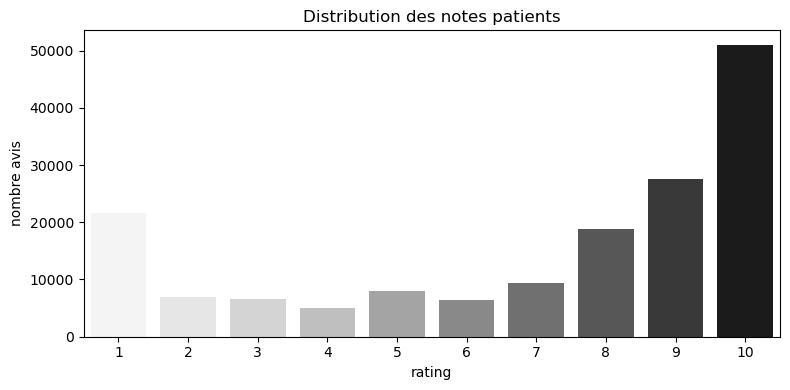

In [110]:
plt.figure(figsize=(8,4))
sns.countplot(x='rating', data=df, palette='Greys')
plt.title('Distribution des notes patients')
plt.xlabel('rating')
plt.ylabel('nombre avis')
plt.tight_layout()
plt.savefig(r'C:\Users\marie\OneDrive\Documents\GitHub\portfolio-data-ia-pharma\projet1-drug-data\dashboard\distribution_ratings.png')
plt.show()

C:\Users\marie\AppData\Local\Temp\ipykernel_22024\1599310092.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_condition.values, y=top_condition.index, palette = 'Blues')


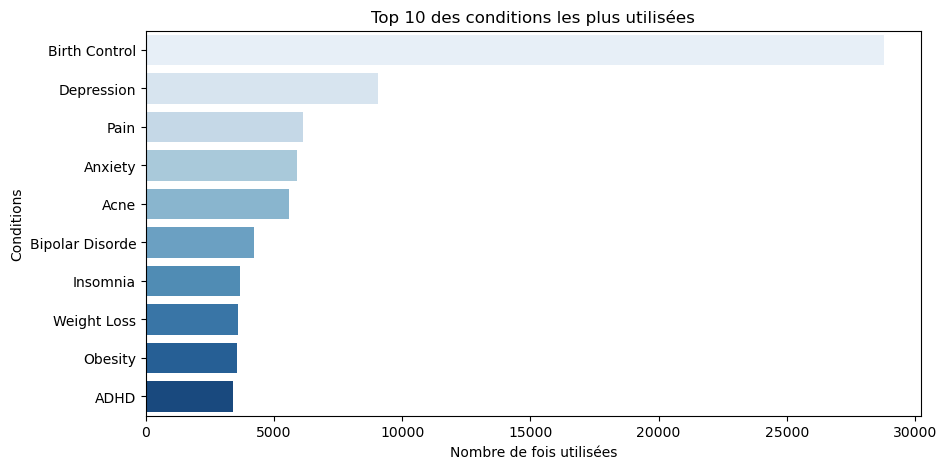

In [75]:
top_condition = df['condition'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_condition.values, y=top_condition.index, palette = 'Blues')
plt.title('Top 10 des conditions les plus utilisées')
plt.xlabel('Nombre de fois utilisées')
plt.ylabel('Conditions')
plt.savefig(r'C:\Users\marie\OneDrive\Documents\GitHub\portfolio-data-ia-pharma\projet1-drug-data\dashboard\distribution_conditions.png')
plt.show()

C:\Users\marie\AppData\Local\Temp\ipykernel_22024\1601029858.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_drugname.values, y=top_drugname.index, palette='Purples_r')


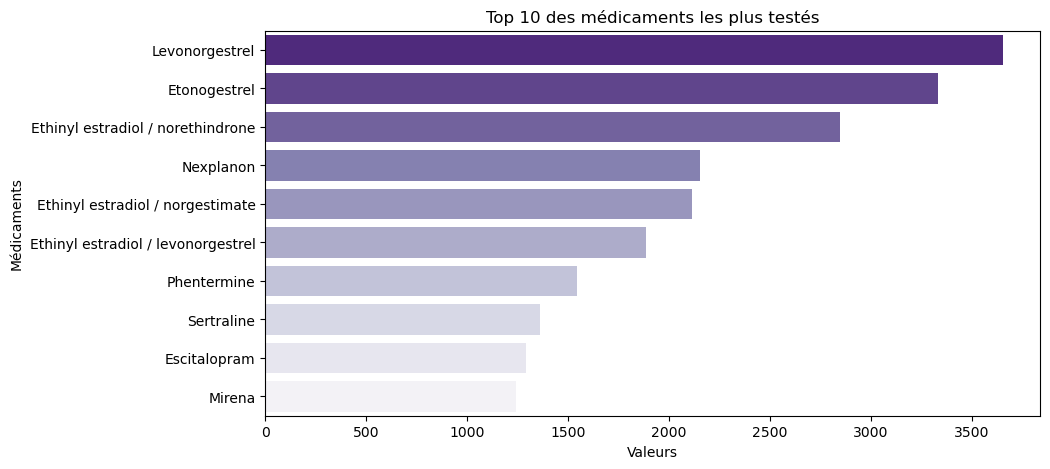

In [76]:
top_drugname=df['drugName'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_drugname.values, y=top_drugname.index, palette='Purples_r')
plt.title('Top 10 des médicaments les plus testés')
plt.xlabel('Valeurs')
plt.ylabel('Médicaments')
plt.savefig(r'C:\Users\marie\OneDrive\Documents\GitHub\portfolio-data-ia-pharma\projet1-drug-data\dashboard\distribution_drugname.png')
plt.show()


In [98]:
connexion = sqlite3.connect(r'C:\Users\marie\OneDrive\Documents\GitHub\portfolio-data-ia-pharma\projet1-drug-data\data\drugsComTrain_raw.db')
df = pd.read_csv(r'C:\Users\marie\OneDrive\Documents\GitHub\portfolio-data-ia-pharma\projet1-drug-data\data\drugsComTrain_raw.csv')
df.to_sql('reviews', connexion, if_exists='replace', index=False)
avis_par_medicament = pd.read_sql_query("SELECT drugName, COUNT(*) as nb_avis FROM reviews GROUP BY drugName", connexion)
print(avis_par_medicament['nb_avis'].describe())
connexion.close()

count    3436.000000
mean       46.943248
std       164.710284
min         1.000000
25%         2.000000
50%         5.000000
75%        26.000000
max      3657.000000
Name: nb_avis, dtype: float64


                                            drugName          condition  \
0                                Silver sulfadiazine    Burns, External   
1                          Drixoral Cold and Allergy      Cold Symptoms   
2               Dexbrompheniramine / pseudoephedrine  Allergic Rhinitis   
3                                           Stribild      HIV Infection   
4  Cobicistat / elvitegravir / emtricitabine / te...      HIV Infection   
5                                     Dimenhydrinate    Nausea/Vomiting   

   note_moyenne  nb_avis  
0      9.972222       36  
1      9.948718       39  
2      9.947368       38  
3      9.475410       61  
4      9.444444       54  
5      9.366667       30  


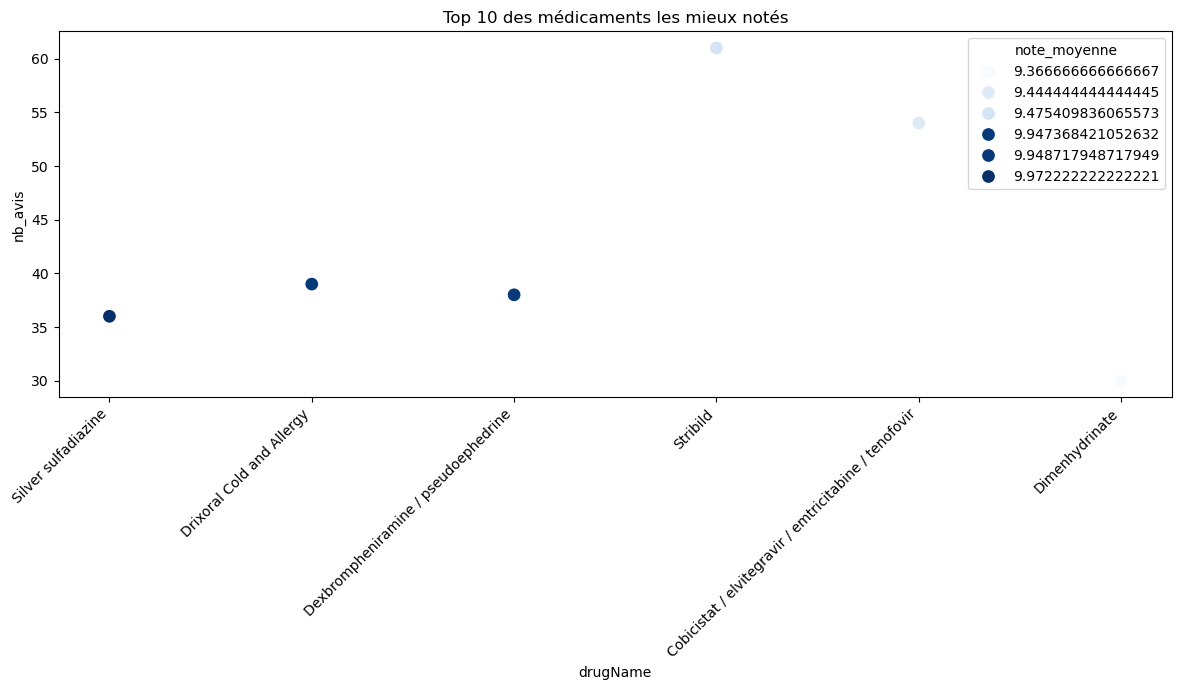

In [108]:
connexion = sqlite3.connect(r'C:\Users\marie\OneDrive\Documents\GitHub\portfolio-data-ia-pharma\projet1-drug-data\data\drugsComTrain_raw.db')
df = pd.read_csv(r'C:\Users\marie\OneDrive\Documents\GitHub\portfolio-data-ia-pharma\projet1-drug-data\data\drugsComTrain_raw.csv')
df.to_sql('reviews', connexion, if_exists='replace', index=False)
resultat = pd.read_sql_query("SELECT drugName, condition, AVG(rating) as note_moyenne, Count(*) as nb_avis FROM reviews GROUP BY drugName HAVING COUNT(*) >= 30 ORDER BY note_moyenne DESC LIMIT 6", connexion)
print(resultat)
connexion.close()
plt.figure(figsize=(12,7))
sns.scatterplot(data = resultat, x= 'drugName', y= 'nb_avis', hue = 'note_moyenne', s=100,  palette='Blues')
plt.title('Top 10 des médicaments les mieux notés')
plt.xticks(rotation=45, ha='right') #Pour rendre les médicaments bien visibles sur l'axe des abscisses
plt.tight_layout()
plt.savefig(r'C:\Users\marie\OneDrive\Documents\GitHub\portfolio-data-ia-pharma\projet1-drug-data\dashboard\Top_drug.png')
plt.show()


**J'ai retenu un seuil minimum de 30 avis par médicament, afin d'écarter les médicaments sous-représentés tout en conservant une diversité suffisante pour l'analyse**